Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
Данные загружены. Размер: (7043, 21)
Первые 5 строк:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...           

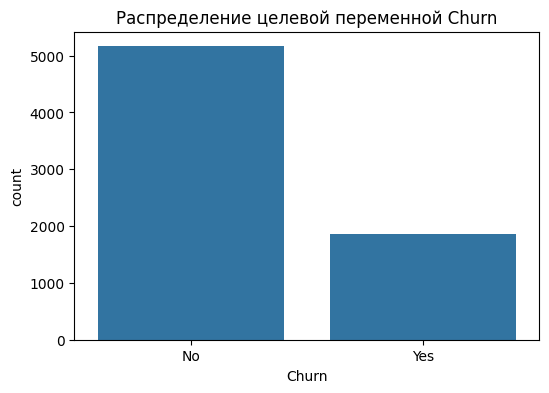

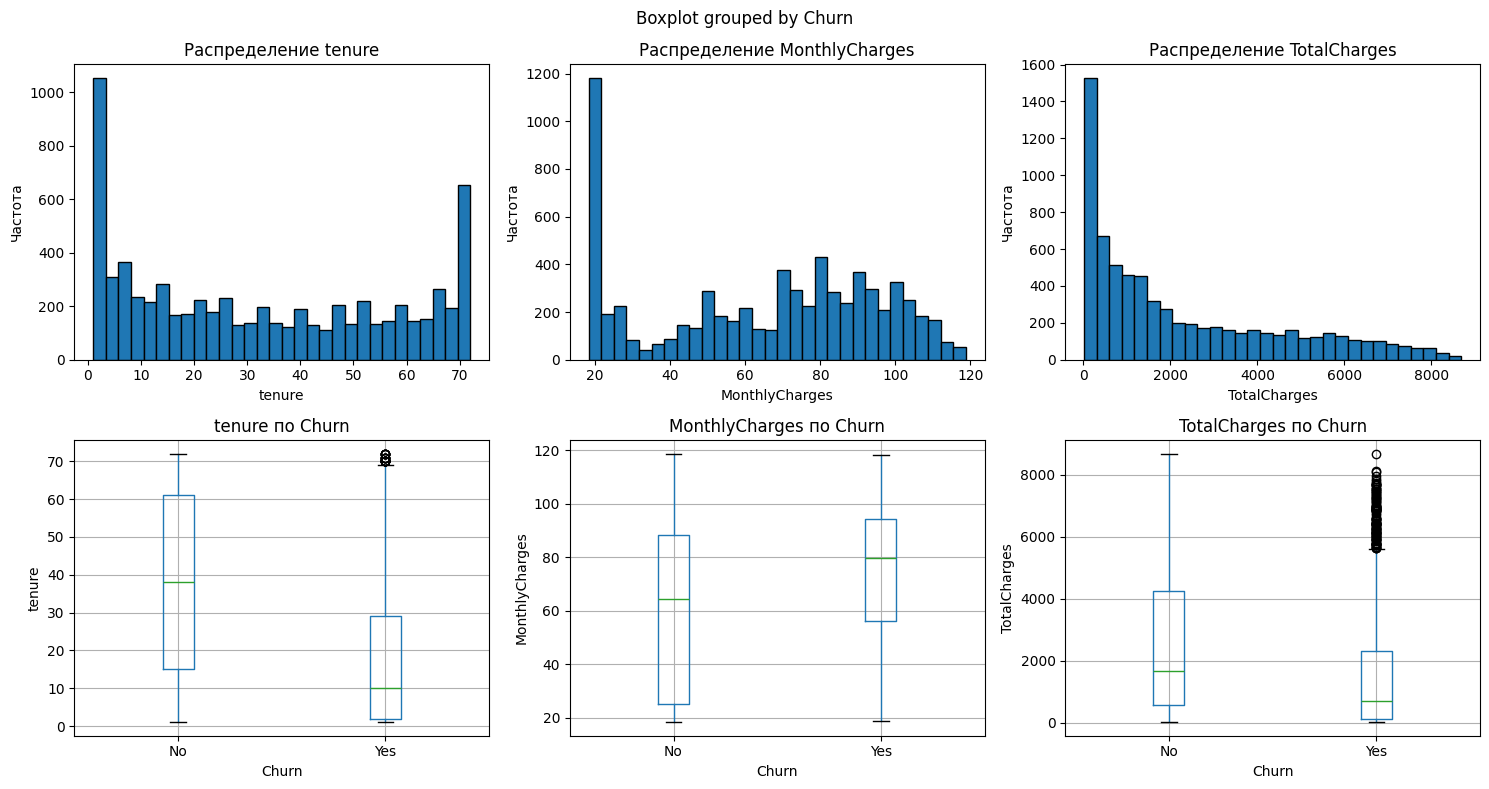

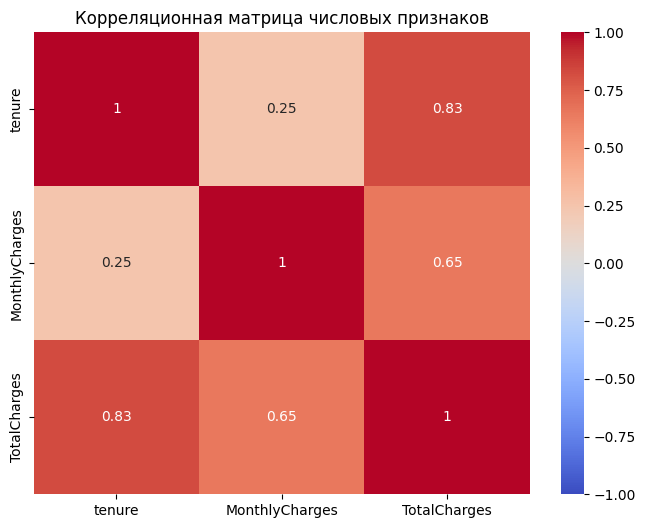

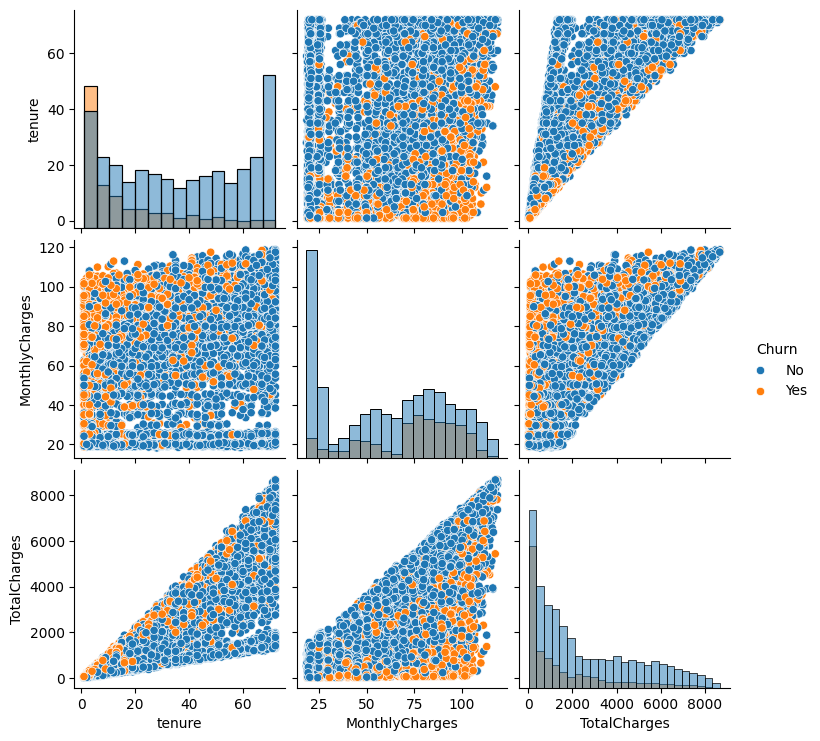


=== КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ===

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


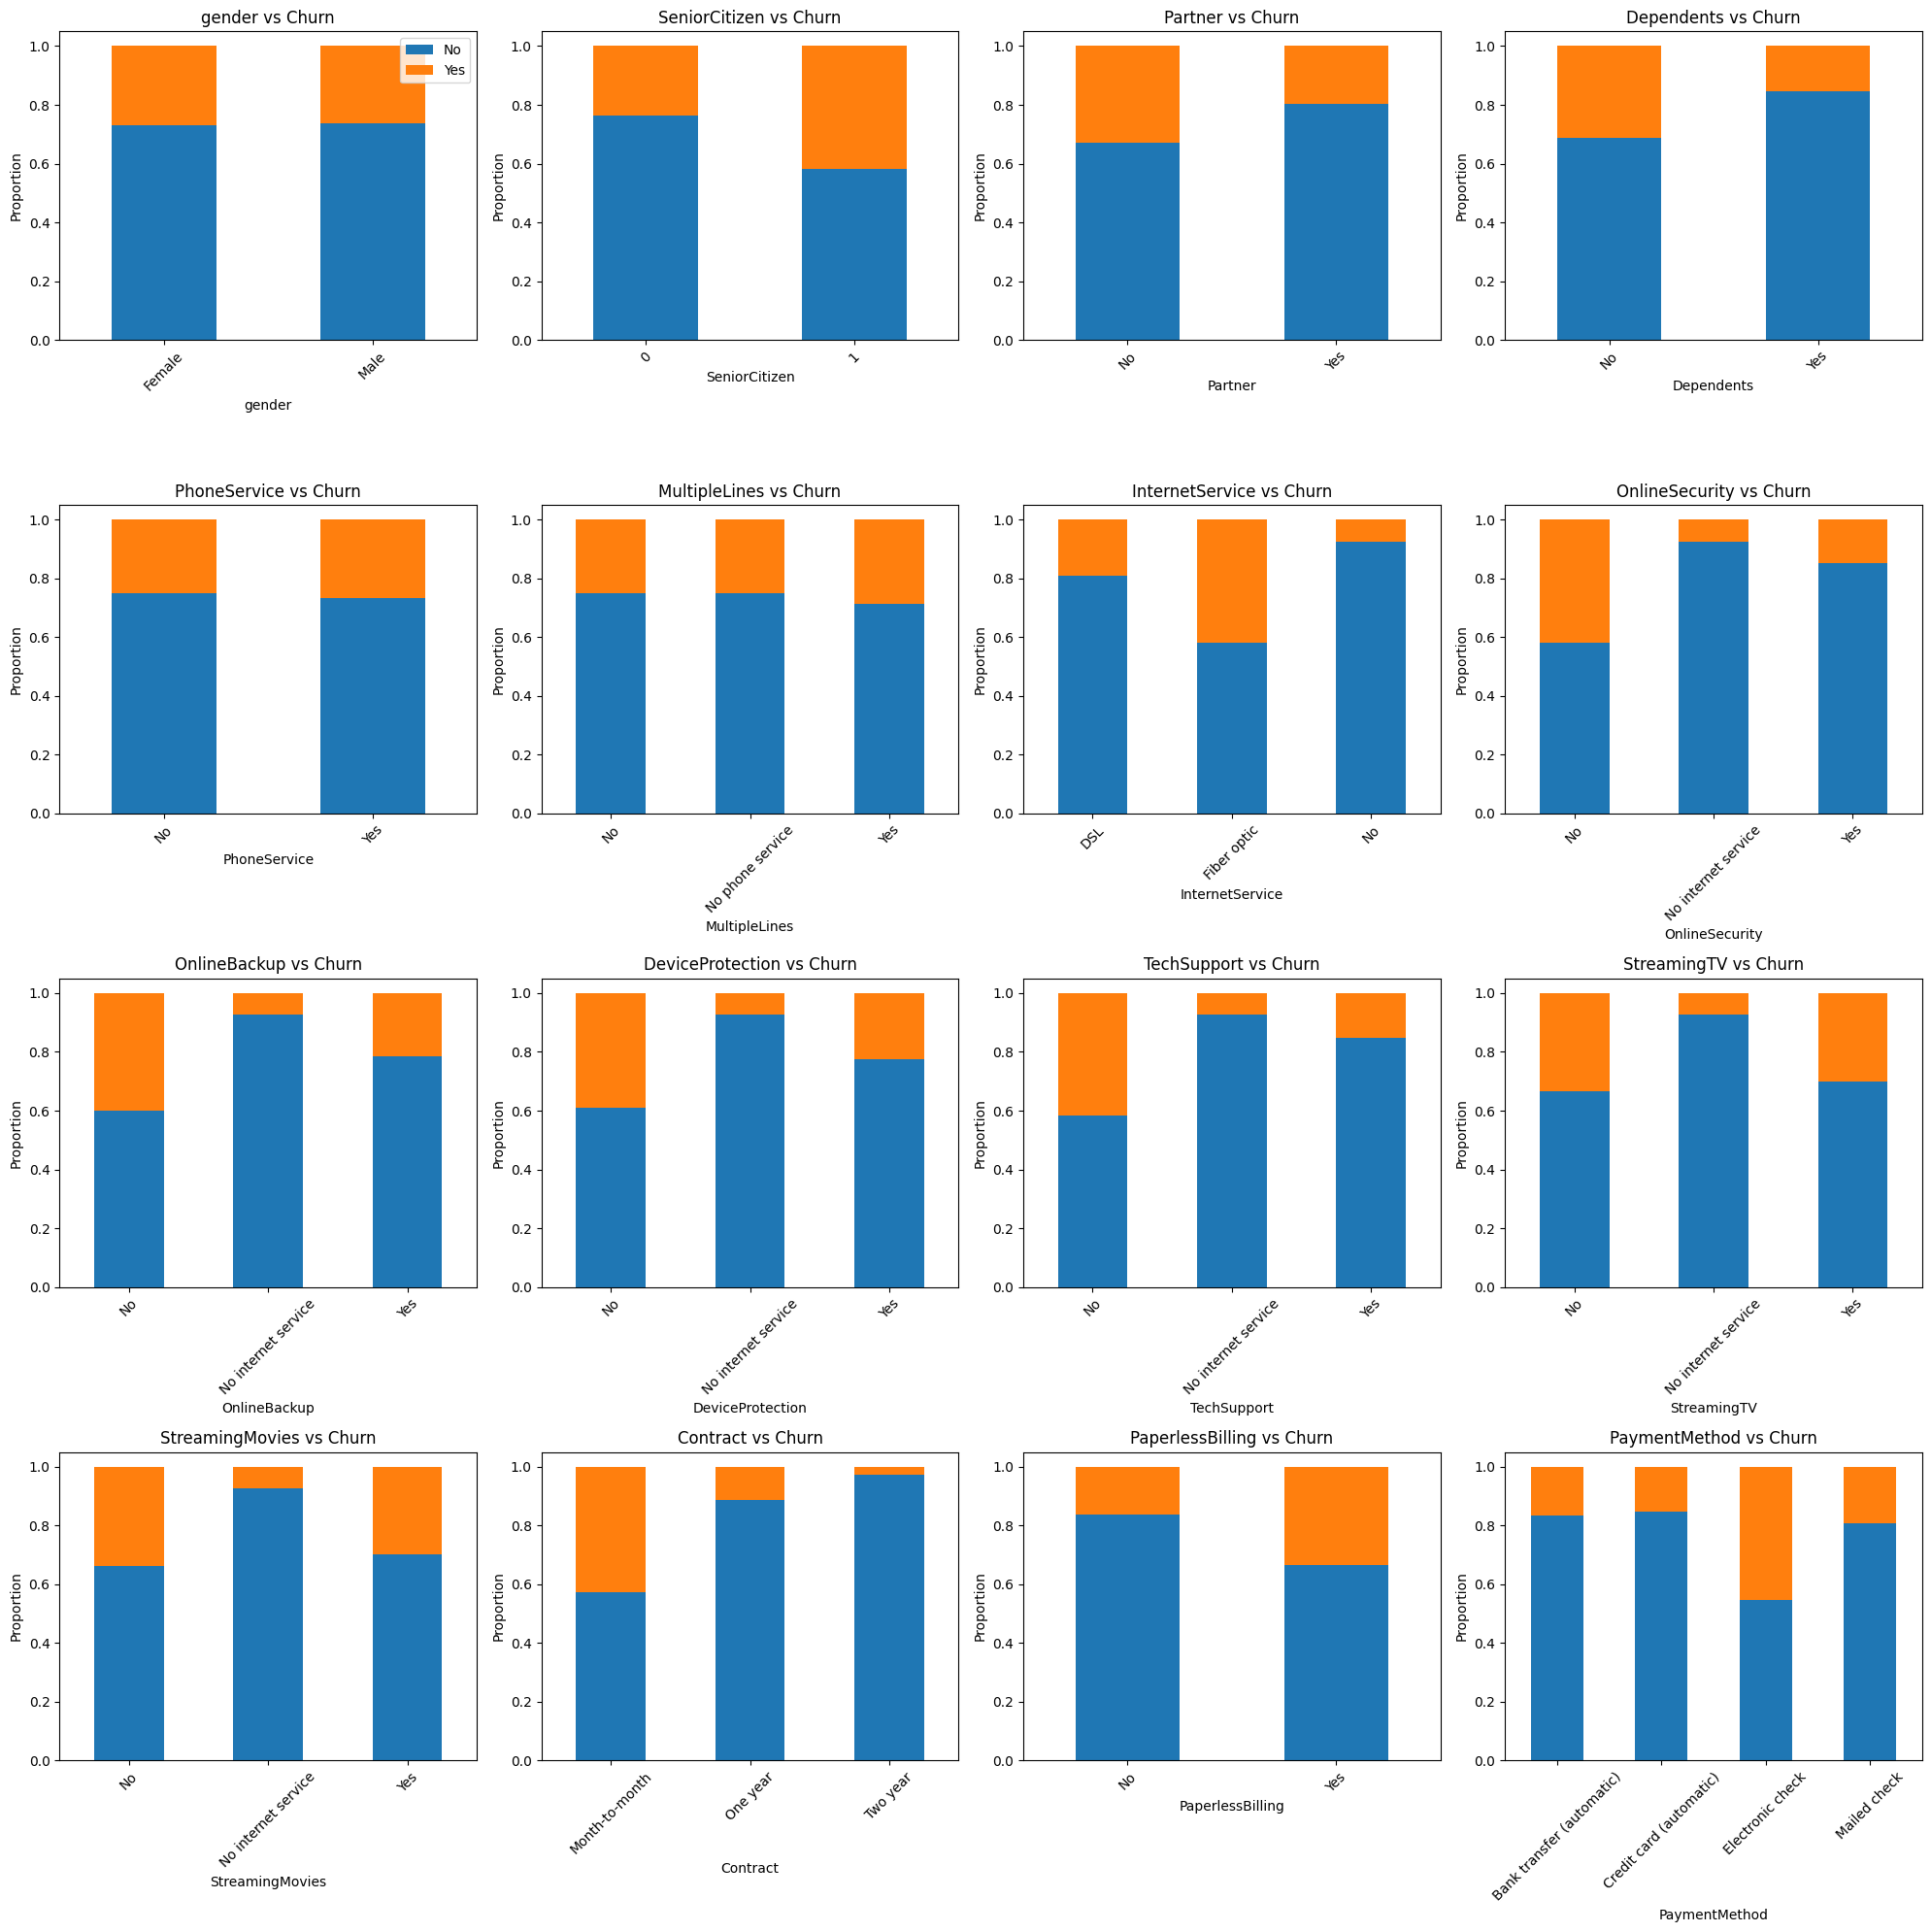


=== Поиск оптимального K для K-Prototypes ===
K=2, cost=32786.24
K=3, cost=23826.15
K=4, cost=21676.91
K=5, cost=19986.07
K=6, cost=18744.60
K=7, cost=17495.36
K=8, cost=16876.02
K=9, cost=16396.78
K=10, cost=15876.83


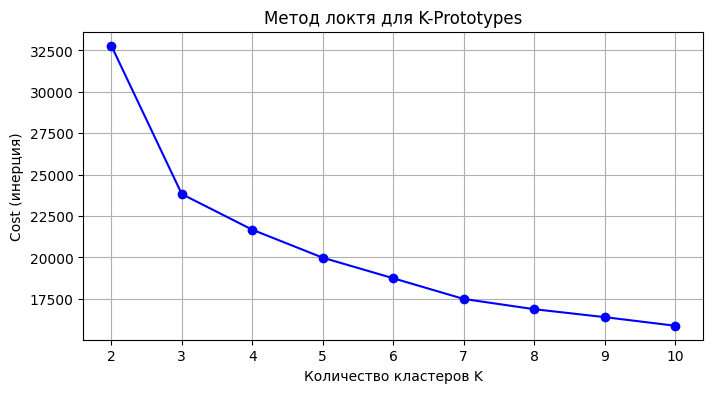

K-Prototypes with K=3 done.
UMAP проекция построена, размер: (7032, 2)


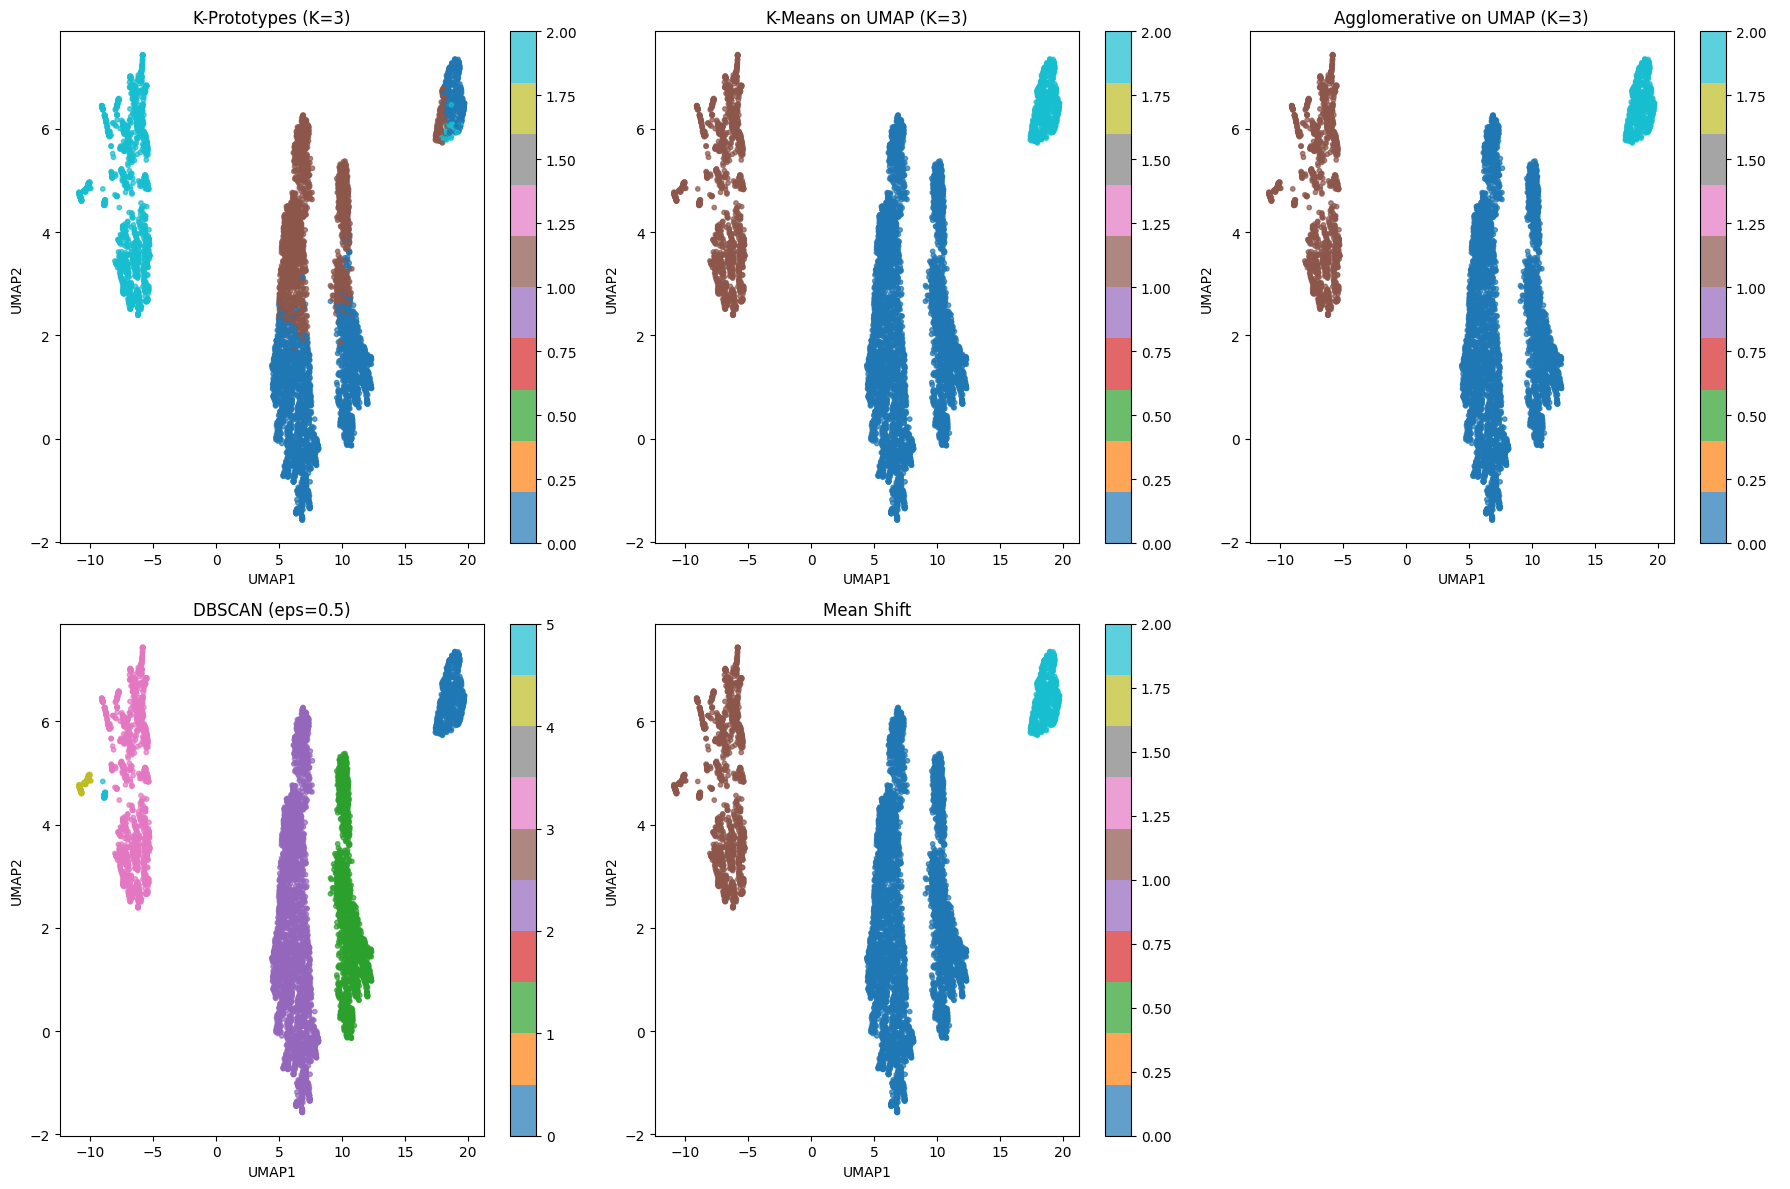


=== Оценка качества кластеризации на UMAP-проекции ===
K-Prototypes: Silhouette=0.3137, DB=1.7191, CH=6431.53
K-Means: Silhouette=0.7289, DB=0.3046, CH=29367.69
Agglomerative: Silhouette=0.7289, DB=0.3046, CH=29367.69
DBSCAN: Silhouette=0.4796, DB=0.6376, CH=23514.06
Mean Shift: Silhouette=0.7289, DB=0.3046, CH=29367.69

=== Logistic Regression ===
Accuracy:  0.8045
Precision: 0.6495
Recall:    0.5749
F1-score:  0.6099
ROC-AUC:   0.8360
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


=== Random Forest ===
Accuracy:  0.7875
Precision: 0.6271
Recall:    0.4947
F1-score:  0.5531
ROC-AUC:   0.8203
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
         

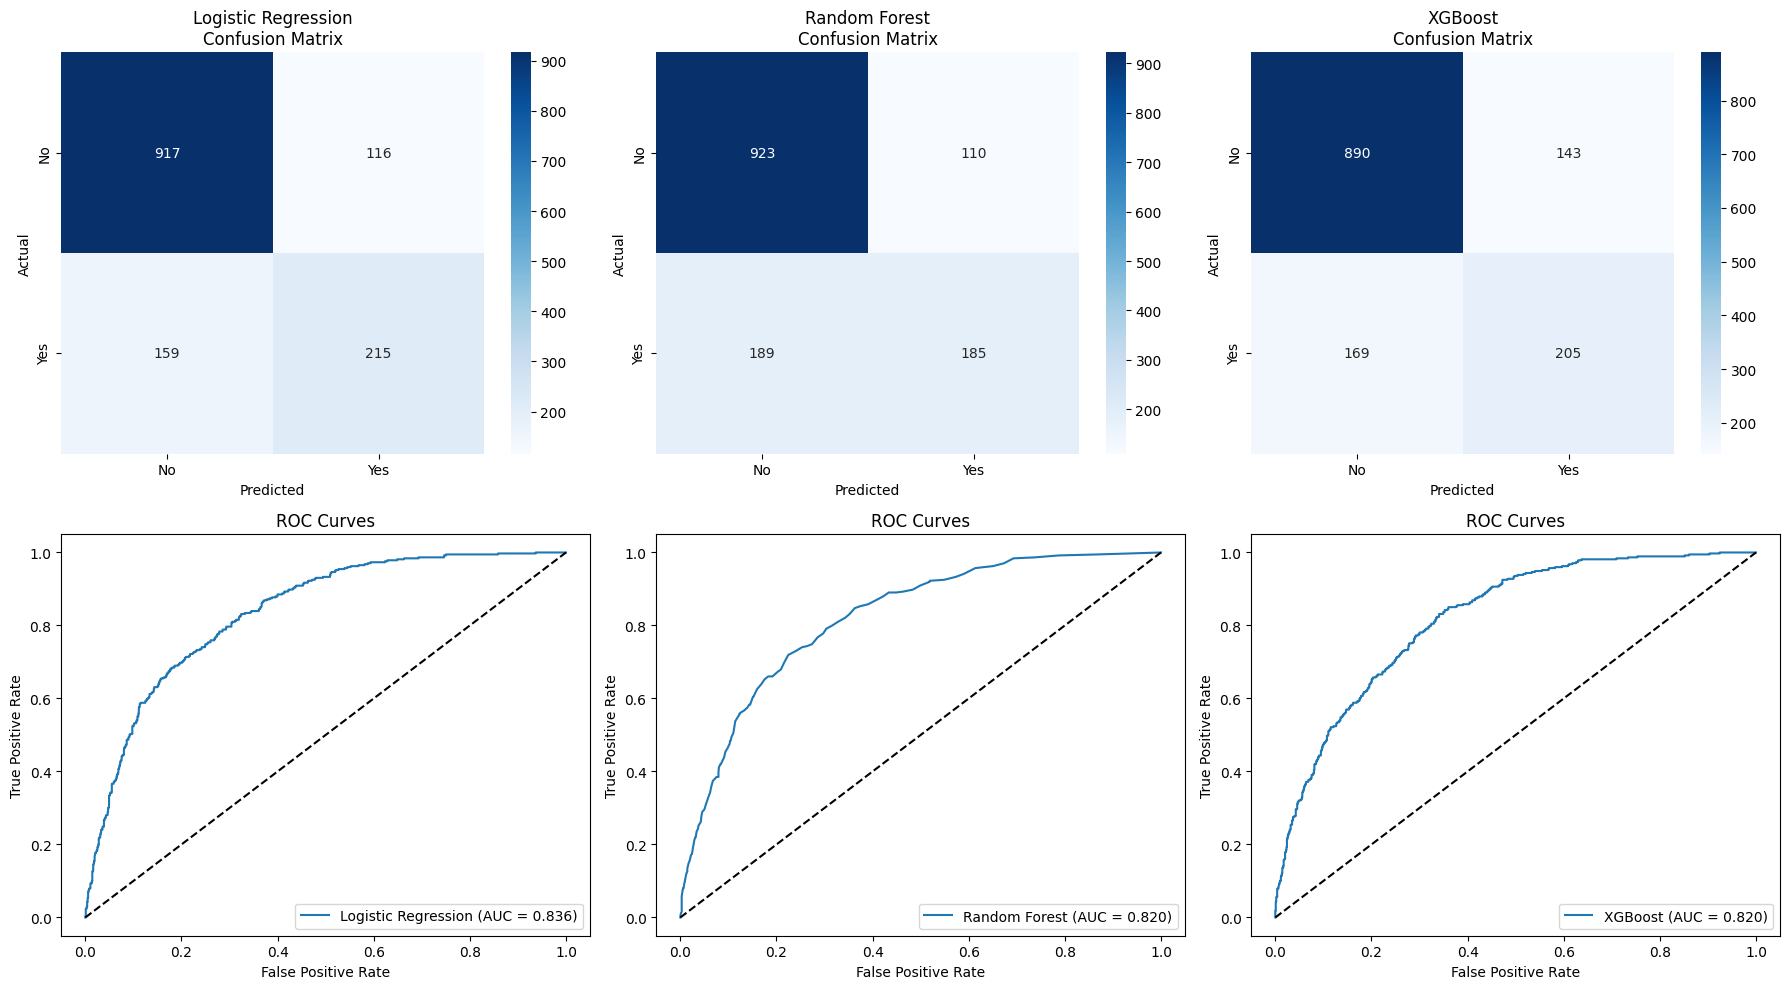


=== Сводная таблица метрик классификации ===
                     accuracy  precision    recall        f1   roc_auc
Logistic Regression  0.804549   0.649547  0.574866  0.609929  0.836014
Random Forest        0.787491   0.627119  0.494652  0.553064  0.820346
XGBoost              0.778252   0.589080  0.548128  0.567867  0.819670


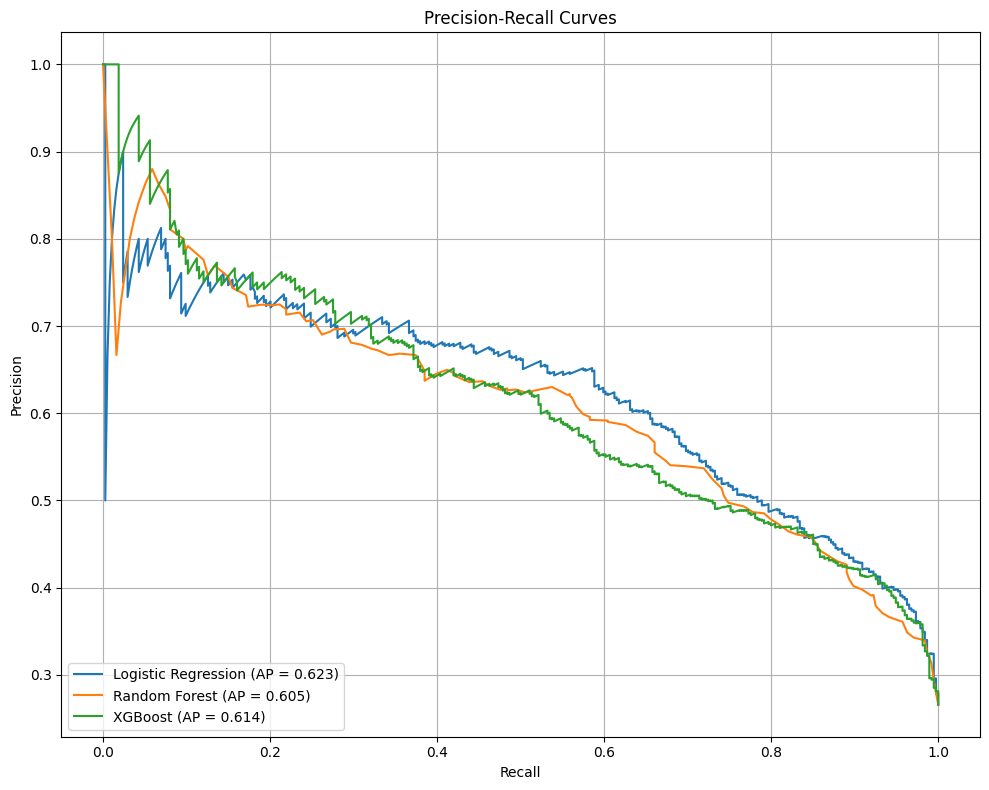

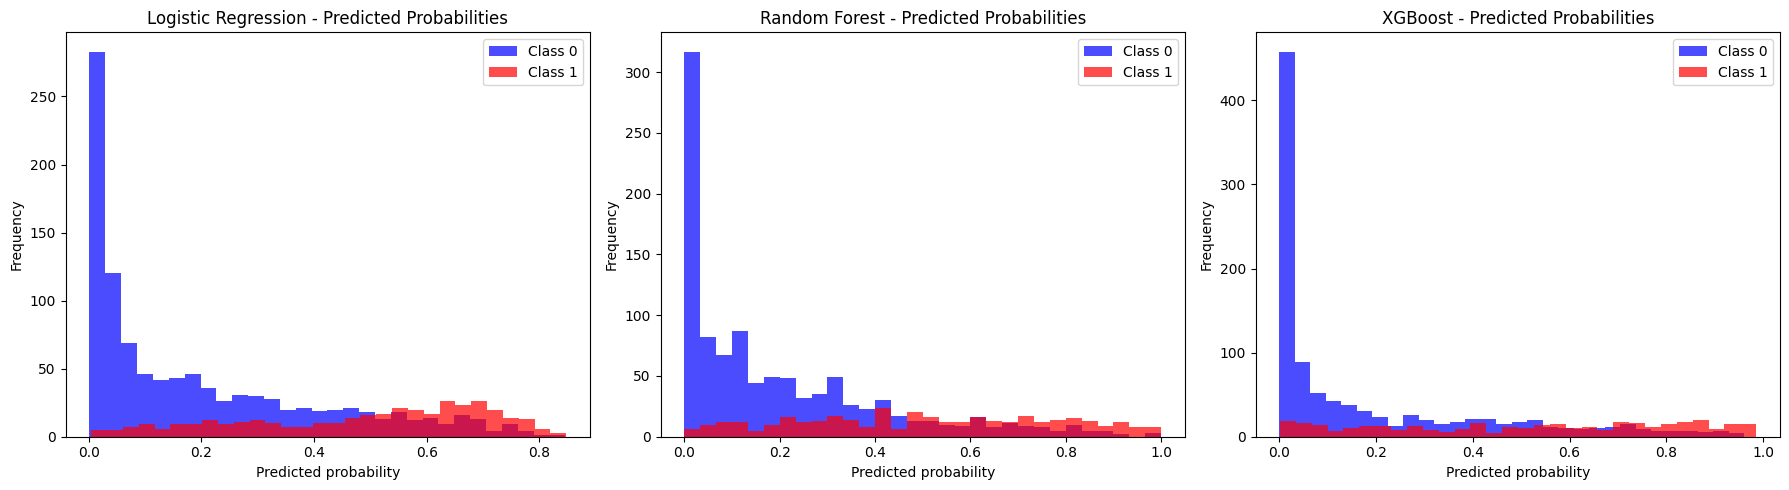

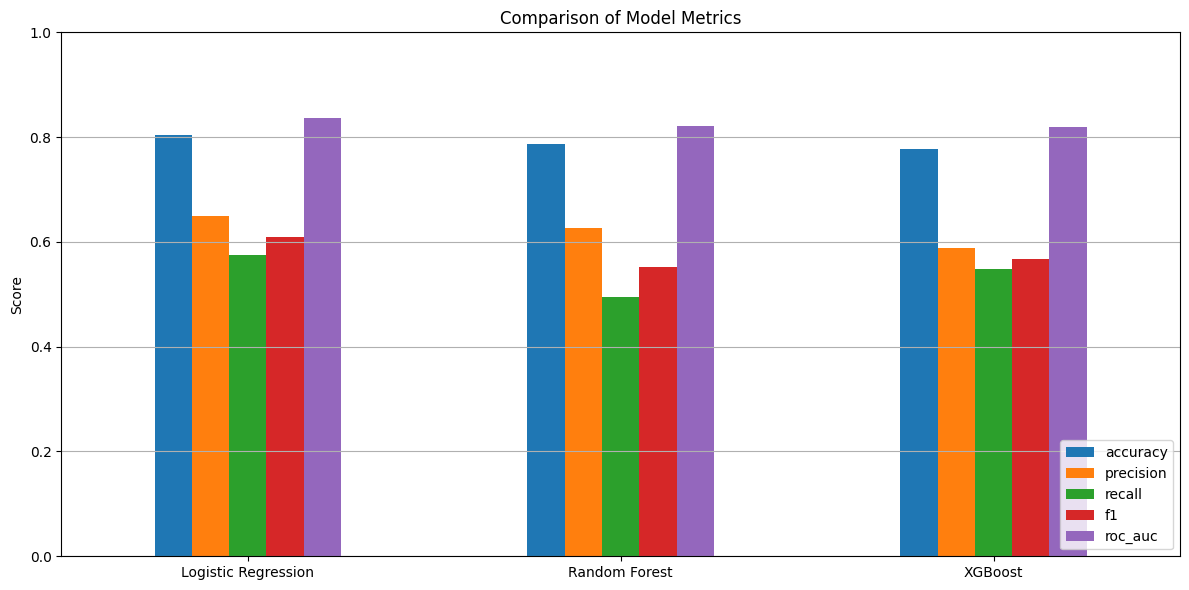

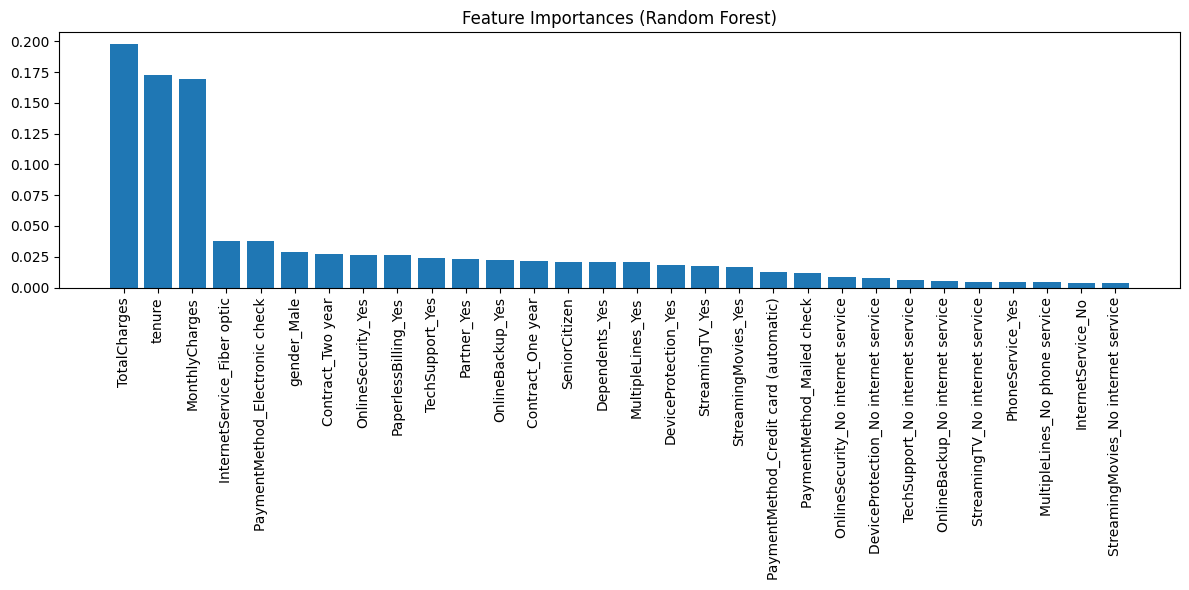


Топ-10 важных признаков:
TotalCharges: 0.1974
tenure: 0.1725
MonthlyCharges: 0.1693
InternetService_Fiber optic: 0.0380
PaymentMethod_Electronic check: 0.0377
gender_Male: 0.0287
Contract_Two year: 0.0273
OnlineSecurity_Yes: 0.0264
PaperlessBilling_Yes: 0.0262
TechSupport_Yes: 0.0236

Isolation Forest: обнаружено аномалий: 352 (5.01%)
PCA reconstruction error: порог 0.0246, аномалий: 352 (5.01%)
Гистограммный метод (3 сигмы): аномалий: 0 (0.00%)


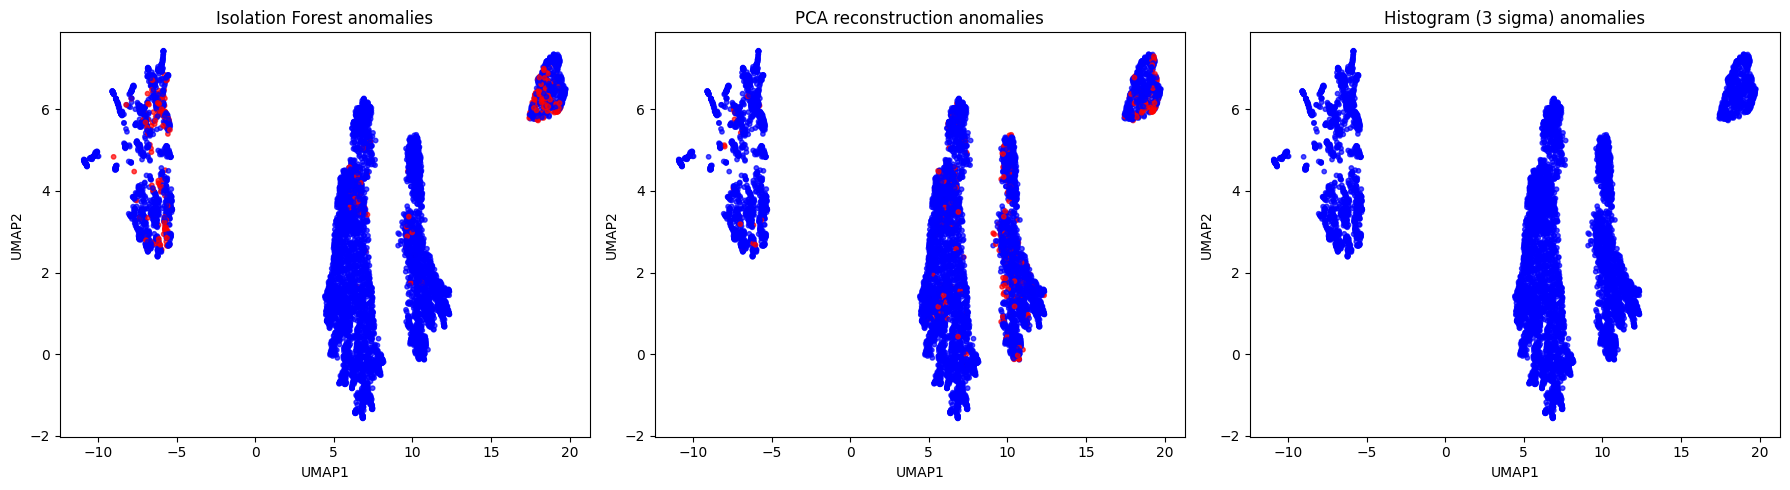


=== Распределение аномалий (Isolation Forest) по кластерам K-Prototypes ===
anomaly_if            -1     1   All
cluster_kprototypes                 
0                     70  3195  3265
1                     90  2085  2175
2                    192  1400  1592
All                  352  6680  7032

=== Распределение аномалий (PCA) по кластерам K-Prototypes ===
anomaly_pca          False  True   All
cluster_kprototypes                   
0                     3080   185  3265
1                     2053   122  2175
2                     1547    45  1592
All                   6680   352  7032

=== Распределение аномалий (Histogram) по кластерам K-Prototypes ===
anomaly_hist         False   All
cluster_kprototypes             
0                     3265  3265
1                     2175  2175
2                     1592  1592
All                   7032  7032


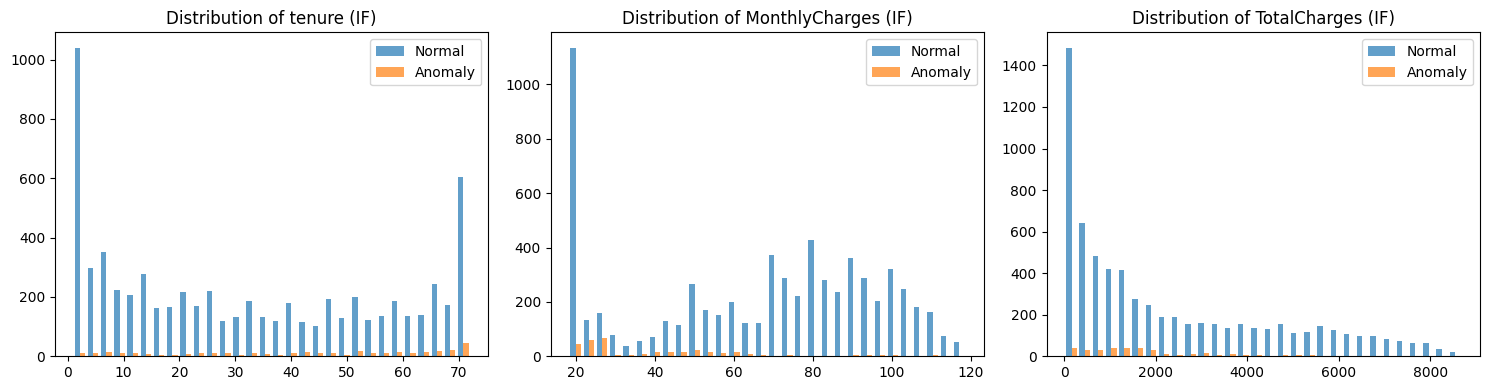

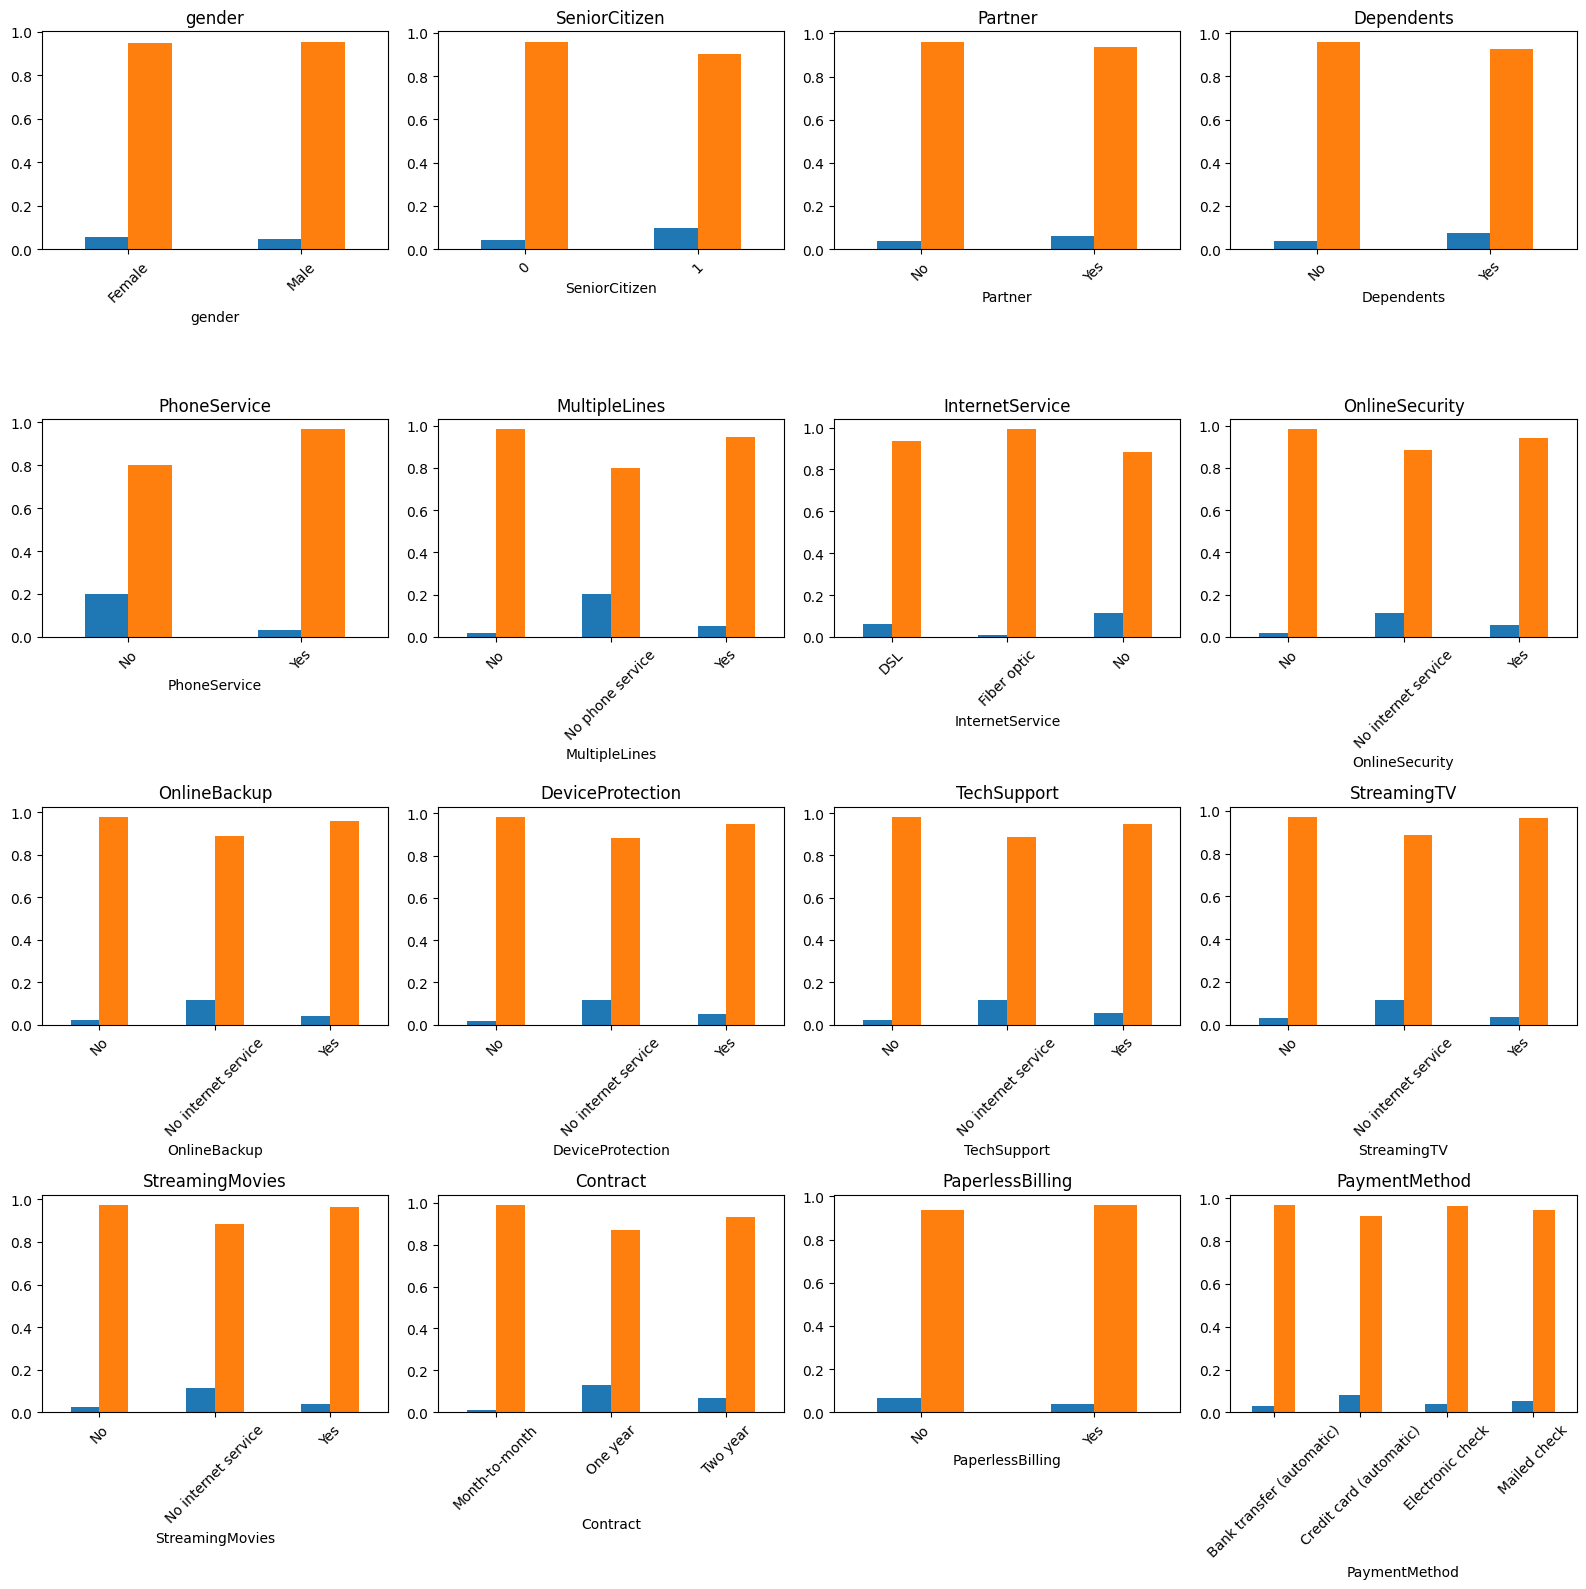

In [11]:
# ============================================================
# 1. УСТАНОВКА НЕОБХОДИМЫХ ПАКЕТОВ
# ============================================================
!pip install pandas numpy matplotlib seaborn scikit-learn umap-learn kmodes
!pip install xgboost

# ============================================================
# 2. ЗАГРУЗКА ДАННЫХ ЧЕРЕЗ KAGGLE API
# ============================================================
import json
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import umap
from kmodes.kprototypes import KPrototypes

import warnings
warnings.filterwarnings('ignore')

# Загружаем kaggle.json (файл с API-ключами)
from google.colab import files
uploaded = files.upload()

# Создаём папку для ключа и перемещаем его
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Скачиваем датасет
!kaggle datasets download -d blastchar/telco-customer-churn

# Распаковываем
with zipfile.ZipFile('telco-customer-churn.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Читаем CSV
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Данные загружены. Размер:", df.shape)
print("Первые 5 строк:")
print(df.head())

# ============================================================
# 3. ПРЕДОБРАБОТКА ДАННЫХ
# ============================================================
# Удаляем строки с пропущенными TotalCharges
df = df[df['TotalCharges'] != ' ']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Удаляем customerID, если он есть
if 'customerID' in df.columns:
    df = df.drop(['customerID'], axis=1)

# Отделяем целевую переменную (Churn) для классификации
if 'Churn' in df.columns:
    y = df['Churn'].map({'Yes': 1, 'No': 0}).values
    X_raw = df.drop(['Churn'], axis=1)
else:
    raise ValueError("В данных нет столбца Churn")

# Списки числовых и категориальных признаков
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in X_raw.columns if col not in numeric_cols]

print("\nЧисловые признаки:", numeric_cols)
print("Категориальные признаки:", categorical_cols)

# Масштабируем числовые признаки
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_raw[numeric_cols])

# Категориальные признаки оставляем как есть (в виде строк) для K-Prototypes
X_cat_original = X_raw[categorical_cols].astype(str)

# One-hot кодирование категориальных признаков (для классификации и обычных методов)
X_cat_dummies = pd.get_dummies(X_raw[categorical_cols], drop_first=True)

# Объединяем масштабированные числовые и one-hot матрицу
X_combined = np.hstack([X_numeric_scaled, X_cat_dummies.values])
feature_names = numeric_cols + list(X_cat_dummies.columns)

print("Размер матрицы для обычных методов (классификация, UMAP):", X_combined.shape)

# ============================================================
# 4. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA) И ОПИСАНИЕ КОЛОНОК
# ============================================================

# Описание колонок на основе документации датасета
column_descriptions = {
    'gender': 'Пол клиента (Male/Female)',
    'SeniorCitizen': 'Является ли клиент пенсионером (1/0)',
    'Partner': 'Есть ли у клиента партнер (Yes/No)',
    'Dependents': 'Есть ли у клиента иждивенцы (Yes/No)',
    'tenure': 'Количество месяцев пользования услугами',
    'PhoneService': 'Наличие телефонной связи (Yes/No)',
    'MultipleLines': 'Наличие нескольких линий (Yes/No/No phone service)',
    'InternetService': 'Тип интернет-услуг (DSL/Fiber optic/No)',
    'OnlineSecurity': 'Онлайн-безопасность (Yes/No/No internet service)',
    'OnlineBackup': 'Онлайн-резервирование (Yes/No/No internet service)',
    'DeviceProtection': 'Защита устройств (Yes/No/No internet service)',
    'TechSupport': 'Техподдержка (Yes/No/No internet service)',
    'StreamingTV': 'Потоковое ТВ (Yes/No/No internet service)',
    'StreamingMovies': 'Потоковое кино (Yes/No/No internet service)',
    'Contract': 'Тип контракта (Month-to-month/One year/Two year)',
    'PaperlessBilling': 'Электронный счет (Yes/No)',
    'PaymentMethod': 'Способ оплаты',
    'MonthlyCharges': 'Ежемесячные платежи',
    'TotalCharges': 'Суммарные платежи',
    'Churn': 'Отток клиента (Yes/No)'
}

print("\n=== ОПИСАНИЕ КОЛОНОК ДАТАСЕТА ===\n")
for col, desc in column_descriptions.items():
    if col in df.columns:
        print(f"{col}: {desc}")

# Проверка пропусков (после предобработки их быть не должно)
print("\n=== ПРОПУСКИ В ДАННЫХ ===\n")
print(df.isnull().sum())

# Общая информация о датасете
print("\n=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===\n")
print(df.info())
print("\n=== ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ ЧИСЛОВЫХ ПРИЗНАКОВ ===\n")
print(df.describe())

# Анализ целевой переменной
print("\n=== РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Churn) ===\n")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
churn_percent = df['Churn'].value_counts(normalize=True) * 100
print(f"\nПроценты:\n{churn_percent}")

# Визуализация целевой переменной
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Распределение целевой переменной Churn')
plt.show()

# Анализ числовых признаков
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(numeric_features):
    # Гистограмма распределения
    axes[0, i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[0, i].set_title(f'Распределение {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Частота')

    # Boxplot в разрезе оттока
    df.boxplot(column=col, by='Churn', ax=axes[1, i])
    axes[1, i].set_title(f'{col} по Churn')
    axes[1, i].set_xlabel('Churn')
    axes[1, i].set_ylabel(col)
plt.tight_layout()
plt.show()

# Корреляционная матрица числовых признаков
corr = df[numeric_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

# Попарные scatter plots с окраской по Churn
sns.pairplot(df, vars=numeric_features, hue='Churn', diag_kind='hist')
plt.show()

# Анализ категориальных признаков
categorical_features = [col for col in df.columns if col not in numeric_features + ['Churn']]
print("\n=== КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ===\n")
print(categorical_features)

# Для каждого категориального признака строим stacked bar chart с долей оттока
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], legend=False)
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)
    if i == 0:
        axes[i].legend(loc='upper right')
# Скрыть лишние подграфики
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# ============================================================
# 5. ОПТИМАЛЬНОЕ ЧИСЛО КЛАСТЕРОВ ДЛЯ K-PROTOTYPES
# ============================================================
# Создаём общий массив для K-Prototypes: числовые + категориальные (в виде строк)
X_cat_array = X_cat_original.values.astype(str)
X_kp = np.hstack([X_numeric_scaled, X_cat_array])
cat_indices = list(range(X_numeric_scaled.shape[1], X_kp.shape[1]))

K_range = range(2, 11)
costs = []

print("\n=== Поиск оптимального K для K-Prototypes ===")
for k in K_range:
    kp = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1, verbose=0)
    kp.fit_predict(X_kp, categorical=cat_indices)
    costs.append(kp.cost_)
    print(f'K={k}, cost={kp.cost_:.2f}')

# Визуализация локтя
plt.figure(figsize=(8,4))
plt.plot(K_range, costs, 'bo-')
plt.xlabel('Количество кластеров K')
plt.ylabel('Cost (инерция)')
plt.title('Метод локтя для K-Prototypes')
plt.grid(True)
plt.show()

# Выберите оптимальное K (например, по изгибу графика)
optimal_k = 3  # замените на выбранное значение

# ============================================================
# 6. КЛАСТЕРИЗАЦИЯ K-PROTOTYPES С ВЫБРАННЫМ K
# ============================================================
kp_final = KPrototypes(n_clusters=optimal_k, init='Cao', random_state=42, n_jobs=-1)
kp_labels = kp_final.fit_predict(X_kp, categorical=cat_indices)
print(f"K-Prototypes with K={optimal_k} done.")

# ============================================================
# 7. UMAP ДЛЯ ВИЗУАЛИЗАЦИИ
# ============================================================
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_umap = reducer.fit_transform(X_combined)
print("UMAP проекция построена, размер:", X_umap.shape)

# ============================================================
# 8. КЛАСТЕРИЗАЦИЯ ДРУГИМИ МЕТОДАМИ (ДЛЯ СРАВНЕНИЯ)
# ============================================================
# K-Means на UMAP
kmeans_umap = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans_umap.fit_predict(X_umap)

# Agglomerative на UMAP
agg = AgglomerativeClustering(n_clusters=optimal_k)
agg_labels = agg.fit_predict(X_umap)

# DBSCAN (автоматическое определение кластеров)
eps = 0.5  # попробуйте разные значения
dbscan = DBSCAN(eps=eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_umap)

# Mean Shift (автоматическое определение)
bandwidth = estimate_bandwidth(X_umap, quantile=0.2)
ms = MeanShift(bandwidth=bandwidth)
ms_labels = ms.fit_predict(X_umap)

# ============================================================
# 9. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# K-Prototypes
ax = axes[0]
sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=kp_labels, cmap='tab10', s=10, alpha=0.7)
ax.set_title(f'K-Prototypes (K={optimal_k})')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.colorbar(sc, ax=ax)

# K-Means
ax = axes[1]
sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=kmeans_labels, cmap='tab10', s=10, alpha=0.7)
ax.set_title(f'K-Means on UMAP (K={optimal_k})')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.colorbar(sc, ax=ax)

# Agglomerative
ax = axes[2]
sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=agg_labels, cmap='tab10', s=10, alpha=0.7)
ax.set_title(f'Agglomerative on UMAP (K={optimal_k})')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.colorbar(sc, ax=ax)

# DBSCAN
ax = axes[3]
sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=dbscan_labels, cmap='tab10', s=10, alpha=0.7)
ax.set_title(f'DBSCAN (eps={eps})')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.colorbar(sc, ax=ax)

# Mean Shift
ax = axes[4]
sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=ms_labels, cmap='tab10', s=10, alpha=0.7)
ax.set_title('Mean Shift')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.colorbar(sc, ax=ax)

# Пустой график
axes[5].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 10. ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ (ДЛЯ МЕТОДОВ С ЗАДАННЫМ K)
# ============================================================
def evaluate_clustering(X, labels, name):
    if len(set(labels)) < 2:
        print(f"{name}: только один кластер – метрики не вычисляются")
        return
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    print(f"{name}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.2f}")

print("\n=== Оценка качества кластеризации на UMAP-проекции ===")
evaluate_clustering(X_umap, kp_labels, "K-Prototypes")
evaluate_clustering(X_umap, kmeans_labels, "K-Means")
evaluate_clustering(X_umap, agg_labels, "Agglomerative")
if len(set(dbscan_labels)) > 1:
    evaluate_clustering(X_umap, dbscan_labels, "DBSCAN")
if len(set(ms_labels)) > 1:
    evaluate_clustering(X_umap, ms_labels, "Mean Shift")

# ============================================================
# 11. ОБУЧЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ И ОЦЕНКА
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

plt.figure(figsize=(18, 10))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Метрики
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc_auc}

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

    # Матрица ошибок
    plt.subplot(2, 3, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'{name}\nConfusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.subplot(2, 3, i+4)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Сводная таблица метрик
results_df = pd.DataFrame(results).T
print("\n=== Сводная таблица метрик классификации ===")
print(results_df)

# ============================================================
# 12. ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: Precision-Recall кривые, гистограммы вероятностей и сравнение метрик
# ============================================================

# 12.1 Precision-Recall кривые
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 12.2 Гистограммы предсказанных вероятностей для каждого класса
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(models.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    ax = axes[i]
    ax.hist(y_proba[y_test == 0], bins=30, alpha=0.7, label='Class 0', color='blue')
    ax.hist(y_proba[y_test == 1], bins=30, alpha=0.7, label='Class 1', color='red')
    ax.set_title(f'{name} - Predicted Probabilities')
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

# 12.3 Сравнение метрик (столбчатая диаграмма)
metrics_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Model Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# 13. ВАЖНОСТЬ ПРИЗНАКОВ (RANDOM FOREST)
# ============================================================
rf = models['Random Forest']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title('Feature Importances (Random Forest)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

print("\nТоп-10 важных признаков:")
for i in indices[:10]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

# ============================================================
# 14. ОБНАРУЖЕНИЕ АНОМАЛИЙ
# ============================================================
# 14.1 Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(X_combined)

n_iso = np.sum(iso_labels == -1)
print(f"\nIsolation Forest: обнаружено аномалий: {n_iso} ({n_iso/len(X_combined)*100:.2f}%)")

# 14.2 PCA-based anomaly detection (reconstruction error)
pca = PCA(n_components=0.95)  # сохраняем 95% дисперсии
X_pca = pca.fit_transform(X_combined)
X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_error = np.mean((X_combined - X_reconstructed)**2, axis=1)

# Определяем порог как 95-й перцентиль ошибки
threshold_pca = np.percentile(reconstruction_error, 95)
pca_anomalies = reconstruction_error > threshold_pca
n_pca = np.sum(pca_anomalies)
print(f"PCA reconstruction error: порог {threshold_pca:.4f}, аномалий: {n_pca} ({n_pca/len(X_combined)*100:.2f}%)")

# 14.3 Гистограммный метод (одномерные выбросы по правилу трёх сигм для числовых признаков)
outliers_hist = np.zeros(len(X_combined), dtype=bool)
for col_idx in range(X_numeric_scaled.shape[1]):
    col_data = X_numeric_scaled[:, col_idx]
    outliers_hist = outliers_hist | (np.abs(col_data) > 3)
n_hist = np.sum(outliers_hist)
print(f"Гистограммный метод (3 сигмы): аномалий: {n_hist} ({n_hist/len(X_combined)*100:.2f}%)")

# Объединяем все метки в один DataFrame для анализа
df_result = X_raw.copy()
df_result['cluster_kprototypes'] = kp_labels
df_result['anomaly_if'] = iso_labels
df_result['anomaly_pca'] = pca_anomalies
df_result['anomaly_hist'] = outliers_hist

# Визуализация аномалий на UMAP-проекции
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Isolation Forest
ax = axes[0]
colors = np.where(iso_labels == 1, 'blue', 'red')
ax.scatter(X_umap[:,0], X_umap[:,1], c=colors, s=10, alpha=0.7)
ax.set_title('Isolation Forest anomalies')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')

# PCA anomalies
ax = axes[1]
colors = np.where(~pca_anomalies, 'blue', 'red')
ax.scatter(X_umap[:,0], X_umap[:,1], c=colors, s=10, alpha=0.7)
ax.set_title('PCA reconstruction anomalies')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')

# Histogram-based (3 sigma)
ax = axes[2]
colors = np.where(~outliers_hist, 'blue', 'red')
ax.scatter(X_umap[:,0], X_umap[:,1], c=colors, s=10, alpha=0.7)
ax.set_title('Histogram (3 sigma) anomalies')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')

plt.tight_layout()
plt.show()

# ============================================================
# 15. АНАЛИЗ АНОМАЛИЙ: распределение по кластерам и гистограммы
# ============================================================
print("\n=== Распределение аномалий (Isolation Forest) по кластерам K-Prototypes ===")
print(pd.crosstab(df_result['cluster_kprototypes'], df_result['anomaly_if'], margins=True))

print("\n=== Распределение аномалий (PCA) по кластерам K-Prototypes ===")
print(pd.crosstab(df_result['cluster_kprototypes'], df_result['anomaly_pca'], margins=True))

print("\n=== Распределение аномалий (Histogram) по кластерам K-Prototypes ===")
print(pd.crosstab(df_result['cluster_kprototypes'], df_result['anomaly_hist'], margins=True))

# Визуализация распределений числовых признаков с выделением аномалий (на примере Isolation Forest)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist([df_result[df_result['anomaly_if']==1][col],
                  df_result[df_result['anomaly_if']==-1][col]],
                 label=['Normal', 'Anomaly'], bins=30, alpha=0.7)
    axes[i].set_title(f'Distribution of {col} (IF)')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Визуализация категориальных признаков с выделением аномалий (Isolation Forest)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df_result[col], df_result['anomaly_if'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], legend=False)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
# скрыть лишние подграфики
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()